# NOTEBOOK 01 — Random-sample feature selection on 41 targets

Цель:
- взять случайную подвыборку train;
- загрузить `train_extra` только для выбранных строк;
- быстро обучить LightGBM по каждому из 41 таргетов;
- агрегировать `gain importance`;
- сохранить `top-700` и `top-300 ⊂ top-700`.

Особенности:
- адаптировано под Kaggle;
- уменьшение типов данных для экономии RAM;
- чтение `train_extra` только для sampled-строк.


In [1]:
!pip install /kaggle/input/notebooks/viktoriasvetankova/lightgbm-gpu-cuda/*.whl

Processing /kaggle/input/notebooks/viktoriasvetankova/lightgbm-gpu-cuda/lightgbm-4.6.0.99-py3-none-linux_x86_64.whl
lightgbm is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


In [2]:
# =========================
# Imports
# =========================
from pathlib import Path
import gc
import json
import warnings

import numpy as np
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import lightgbm as lgb

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)


polars.config.Config

In [3]:
# =========================
# Paths
# =========================
DATA_DIR = Path("/kaggle/input/datasets/hatab123/data-fusion-contest-2026/")
WORK_DIR = Path("/kaggle/working/prepared")
WORK_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    "train_main": DATA_DIR / "train_main_features.parquet",
    "train_extra": DATA_DIR / "train_extra_features.parquet",
    "train_target": DATA_DIR / "train_target.parquet",
    "test_main": DATA_DIR / "test_main_features.parquet",
    "test_extra": DATA_DIR / "test_extra_features.parquet",
    "sample_submit": DATA_DIR / "sample_submit.parquet",
}

ARTIFACTS_DIR = WORK_DIR / "artifacts"
SELECTED_DIR = ARTIFACTS_DIR / "selected_features"
LOG_DIR = ARTIFACTS_DIR / "logs"

SELECTED_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("WORK_DIR:", WORK_DIR)
for name, path in PATHS.items():
    print(f"{name:>14}: {path} | exists={path.exists()}")


DATA_DIR: /kaggle/input/datasets/hatab123/data-fusion-contest-2026
WORK_DIR: /kaggle/working/prepared
    train_main: /kaggle/input/datasets/hatab123/data-fusion-contest-2026/train_main_features.parquet | exists=True
   train_extra: /kaggle/input/datasets/hatab123/data-fusion-contest-2026/train_extra_features.parquet | exists=True
  train_target: /kaggle/input/datasets/hatab123/data-fusion-contest-2026/train_target.parquet | exists=True
     test_main: /kaggle/input/datasets/hatab123/data-fusion-contest-2026/test_main_features.parquet | exists=True
    test_extra: /kaggle/input/datasets/hatab123/data-fusion-contest-2026/test_extra_features.parquet | exists=True
 sample_submit: /kaggle/input/datasets/hatab123/data-fusion-contest-2026/sample_submit.parquet | exists=True


In [4]:
# =========================
# Config
# =========================
SEED = 42
SAMPLE_ROWS = 200_000          # random sample size for selector stage
TOP700_K = 700
TOP300_K = 300

# fast LightGBM selector params
LGB_PARAMS = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.10,
    "num_leaves": 31,
    "feature_fraction": 0.80,
    "verbose": -1,
    "seed": SEED,
    "device": "cuda",
    "gpu_use_dp": False,
    "num_threads": 2,
}
NUM_BOOST_ROUND = 50           # short scan over all 41 targets
MIN_POSITIVE_ROWS = 30         # skip pathological targets in the sampled subset if needed


In [5]:
# =========================
# Helpers
# =========================
def read_schema_columns(parquet_path: Path):
    pf = pq.ParquetFile(parquet_path)
    return pf.schema_arrow.names

def save_json_list(path: Path, values):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(list(values), f, ensure_ascii=False, indent=2)

def report_mem_pl(df: pl.DataFrame, name: str):
    mem_mb = df.estimated_size() / 1024**2
    print(f"{name}: shape={df.shape}, memory={mem_mb:,.2f} MB")

def downcast_pl(df: pl.DataFrame) -> pl.DataFrame:
    exprs = []
    for col, dtype in zip(df.columns, df.dtypes):
        if dtype == pl.Float64:
            exprs.append(pl.col(col).cast(pl.Float32))
        elif dtype == pl.Int64:
            exprs.append(pl.col(col).cast(pl.Int32))
        elif dtype == pl.UInt64:
            exprs.append(pl.col(col).cast(pl.UInt32))
        else:
            exprs.append(pl.col(col))
    return df.select(exprs)

def load_target_full(path: Path) -> pl.DataFrame:
    df = pl.read_parquet(path)
    return downcast_pl(df)

def load_parquet_rows_by_indices_pl(parquet_path: Path, row_indices, columns=None) -> pl.DataFrame:
    """
    Читает только выбранные строки из parquet через row groups.
    Возвращает polars.DataFrame.
    """
    row_indices = np.asarray(sorted(set(int(i) for i in row_indices)), dtype=np.int64)
    pf = pq.ParquetFile(parquet_path)

    parts = []
    global_start = 0
    ptr = 0
    n_need = len(row_indices)

    for rg in range(pf.num_row_groups):
        if ptr >= n_need:
            break

        rg_rows = pf.metadata.row_group(rg).num_rows
        global_end = global_start + rg_rows

        left = ptr
        while left < n_need and row_indices[left] < global_start:
            left += 1
        right = left
        while right < n_need and row_indices[right] < global_end:
            right += 1

        if right > left:
            local_idx = row_indices[left:right] - global_start
            table = pf.read_row_group(rg, columns=columns)
            picked = table.take(pa.array(local_idx))
            df_part = pl.from_arrow(picked)
            parts.append(df_part)

            del table, picked, df_part
            gc.collect()

        ptr = right
        global_start = global_end

    if not parts:
        cols = columns if columns is not None else []
        return pl.DataFrame({c: [] for c in cols})

    result = pl.concat(parts, how="vertical_relaxed")
    result = downcast_pl(result)

    del parts
    gc.collect()
    return result

def sample_row_indices(n_rows: int, sample_size: int, seed: int = 42):
    sample_size = min(sample_size, n_rows)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n_rows, size=sample_size, replace=False))

def safe_binary_target_stats(y: np.ndarray):
    pos = int(y.sum())
    neg = int((1 - y).sum())
    return pos, neg


In [6]:
# =========================
# Read target + identify columns
# =========================
target_df = load_target_full(PATHS["train_target"])
report_mem_pl(target_df, "target_df")

target_cols = [c for c in target_df.columns if c != "customer_id"]
id_col = "customer_id"

print(f"id_col: {id_col}")
print(f"target columns: {len(target_cols)}")
print(target_cols[:5], "...")


target_df: shape=(750000, 42), memory=120.16 MB
id_col: customer_id
target columns: 41
['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5'] ...


In [7]:
# =========================
# Random sample of rows for selector stage
# =========================
n_rows = target_df.height
sample_indices = sample_row_indices(n_rows=n_rows, sample_size=SAMPLE_ROWS, seed=SEED)

print(f"Total train rows:  {n_rows:,}")
print(f"Sample rows:       {len(sample_indices):,}")
print(f"Sample share:      {len(sample_indices) / n_rows:.2%}")

target_df = target_df.with_row_index("row_idx")
sample_target_df = (
    target_df
    .filter(pl.col("row_idx").is_in(sample_indices))
    .drop("row_idx")
)
report_mem_pl(sample_target_df, "sample_target_df")

sample_idx_df = pl.DataFrame({
    "row_idx": pl.Series("row_idx", sample_indices, dtype=pl.Int64),
    id_col: sample_target_df.get_column(id_col),
})
sample_idx_path = SELECTED_DIR / "sample_indices.parquet"
sample_idx_df.write_parquet(sample_idx_path)

print(f"Saved sampled indices: {sample_idx_path}")


Total train rows:  750,000
Sample rows:       200,000
Sample share:      26.67%
sample_target_df: shape=(200000, 42), memory=32.04 MB
Saved sampled indices: /kaggle/working/prepared/artifacts/selected_features/sample_indices.parquet


In [8]:
# =========================
# Read extra schema and load only sampled rows
# =========================
extra_cols = read_schema_columns(PATHS["train_extra"])
assert id_col in extra_cols, f"{id_col} not found in train_extra"

extra_feature_cols = [c for c in extra_cols if c != id_col]
print(f"Extra feature columns: {len(extra_feature_cols):,}")
print(extra_feature_cols[:5], "...")

needed_cols = [id_col] + extra_feature_cols

df_extra_sample = load_parquet_rows_by_indices_pl(
    PATHS["train_extra"],
    row_indices=sample_indices,
    columns=needed_cols,
)
report_mem_pl(df_extra_sample, "df_extra_sample (loaded only sampled rows)")

loaded_ids = df_extra_sample.get_column(id_col)
target_ids = sample_target_df.get_column(id_col)
assert df_extra_sample.height == sample_target_df.height, "Row count mismatch"
assert loaded_ids.equals(target_ids), "customer_id alignment mismatch"

df_extra_sample = df_extra_sample.drop(id_col)
report_mem_pl(df_extra_sample, "df_extra_sample (features only)")


Extra feature columns: 2,241
['num_feature_133', 'num_feature_134', 'num_feature_135', 'num_feature_136', 'num_feature_137'] ...
df_extra_sample (loaded only sampled rows): shape=(200000, 2242), memory=1,763.93 MB
df_extra_sample (features only): shape=(200000, 2241), memory=1,763.17 MB


device_type='gpu' работает
- значит его используем в параметрах модели LGBM

In [9]:
# =========================
# Prepare matrices for LightGBM
# =========================
X = df_extra_sample.to_numpy()
if X.dtype != np.float32:
    X = X.astype(np.float32, copy=False)

print("X shape:", X.shape, "| dtype:", X.dtype)

sample_target_df = downcast_pl(sample_target_df)
report_mem_pl(sample_target_df, "sample_target_df (downcasted)")

del df_extra_sample
gc.collect()


X shape: (200000, 2241) | dtype: float32
sample_target_df (downcasted): shape=(200000, 42), memory=32.04 MB


0

Positive class stats in sampled dataset:
shape: (41, 3)
┌─────────────┬────────────────┬───────────────┐
│ target      ┆ positive_count ┆ positive_rate │
│ ---         ┆ ---            ┆ ---           │
│ str         ┆ i64            ┆ f64           │
╞═════════════╪════════════════╪═══════════════╡
│ target_10_1 ┆ 63227          ┆ 0.316135      │
│ target_9_6  ┆ 44485          ┆ 0.222425      │
│ target_8_1  ┆ 20430          ┆ 0.10215       │
│ target_3_2  ┆ 19557          ┆ 0.097785      │
│ target_3_1  ┆ 19498          ┆ 0.09749       │
│ target_9_7  ┆ 15447          ┆ 0.077235      │
│ target_7_1  ┆ 12361          ┆ 0.061805      │
│ target_9_2  ┆ 7382           ┆ 0.03691       │
│ target_8_2  ┆ 6581           ┆ 0.032905      │
│ target_7_2  ┆ 5581           ┆ 0.027905      │
│ …           ┆ …              ┆ …             │
│ target_2_5  ┆ 389            ┆ 0.001945      │
│ target_1_5  ┆ 378            ┆ 0.00189       │
│ target_3_4  ┆ 376            ┆ 0.00188       │
│ target_9_4 

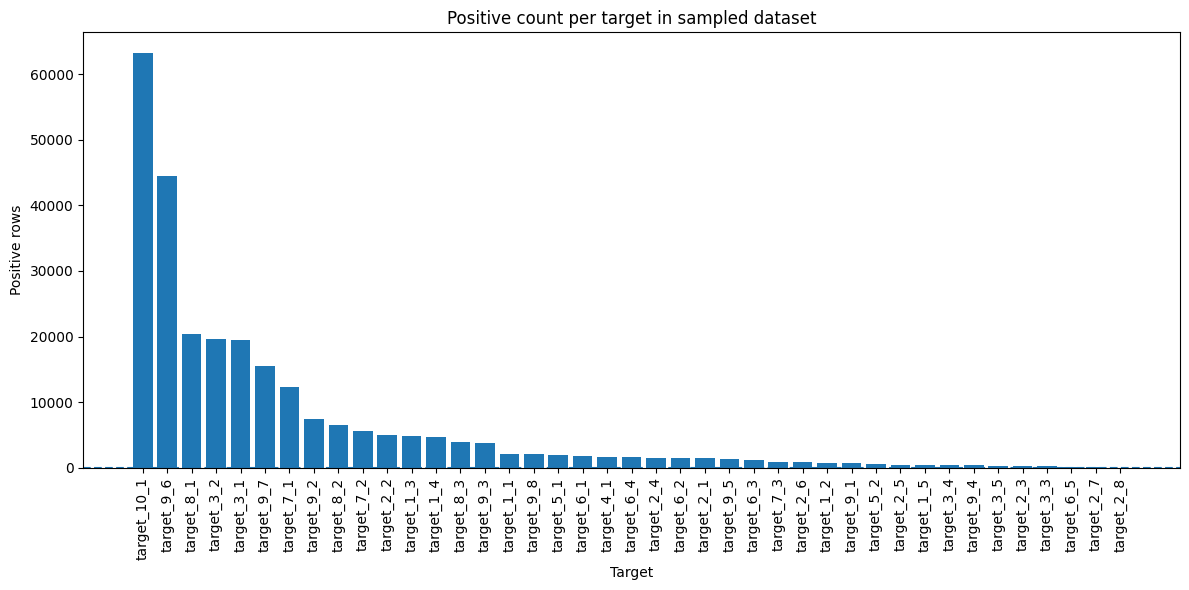

In [12]:
# =========================
# Positive class stats in sampled targets
# =========================
import matplotlib.pyplot as plt

pos_rows = []
n_sample = sample_target_df.height

for tgt in target_cols:
    pos_count = int(sample_target_df.get_column(tgt).sum())
    pos_rate = pos_count / n_sample if n_sample > 0 else 0.0
    pos_rows.append((tgt, pos_count, pos_rate))

pos_stats_df = pl.DataFrame(
    pos_rows,
    schema=["target", "positive_count", "positive_rate"]
).sort("positive_count", descending=True)

print("Positive class stats in sampled dataset:")
print(pos_stats_df)

print("\nTargets with positive_count < MIN_POSITIVE_ROWS:")
print(
    pos_stats_df
    .filter(pl.col("positive_count") < MIN_POSITIVE_ROWS)
    .sort("positive_count")
)

# optional save
pos_stats_path = SELECTED_DIR / "sample_target_positive_stats.csv"
pos_stats_df.write_csv(pos_stats_path)
print(f"\nSaved: {pos_stats_path}")

# plot
plot_df = pos_stats_df.to_pandas()

plt.figure(figsize=(12, 6))
plt.bar(plot_df["target"], plot_df["positive_count"])
plt.axhline(MIN_POSITIVE_ROWS, linestyle="--")
plt.xticks(rotation=90)
plt.title("Positive count per target in sampled dataset")
plt.ylabel("Positive rows")
plt.xlabel("Target")
plt.tight_layout()
plt.show()

In [13]:
# =========================
# Fast LightGBM feature scan over all 41 targets
# =========================
feature_names = extra_feature_cols
n_features = len(feature_names)

sum_gain = np.zeros(n_features, dtype=np.float64)
sum_split = np.zeros(n_features, dtype=np.int64)
coverage = np.zeros(n_features, dtype=np.int32)

target_scan_log = []

for i, tgt in enumerate(target_cols, start=1):
    y = sample_target_df.get_column(tgt).to_numpy()
    y = np.asarray(y, dtype=np.int8)

    pos, neg = safe_binary_target_stats(y)
    print(f"[{i:02d}/{len(target_cols)}] {tgt} | positives={pos:,} | negatives={neg:,}")

    if pos < MIN_POSITIVE_ROWS or neg < MIN_POSITIVE_ROWS:
        print("  -> skipped: too few positive/negative rows in sample")
        target_scan_log.append({
            "target": tgt,
            "positives": pos,
            "negatives": neg,
            "used": 0,
        })
        continue

    train_set = lgb.Dataset(X, label=y, feature_name=feature_names, free_raw_data=False)
    booster = lgb.train(
        params=LGB_PARAMS,
        train_set=train_set,
        num_boost_round=NUM_BOOST_ROUND,
    )

    gain = np.asarray(booster.feature_importance(importance_type="gain"), dtype=np.float64)
    split = np.asarray(booster.feature_importance(importance_type="split"), dtype=np.int64)

    sum_gain += gain
    sum_split += split
    coverage += (gain > 0).astype(np.int32)

    target_scan_log.append({
        "target": tgt,
        "positives": pos,
        "negatives": neg,
        "used": 1,
        "nonzero_gain_features": int((gain > 0).sum()),
        "sum_gain_target": float(gain.sum()),
    })

    del train_set, booster, y, gain, split
    gc.collect()

print("Finished all targets.")


[01/41] target_1_1 | positives=2,123 | negatives=197,877
[02/41] target_1_2 | positives=692 | negatives=199,308
[03/41] target_1_3 | positives=4,826 | negatives=195,174
[04/41] target_1_4 | positives=4,687 | negatives=195,313
[05/41] target_1_5 | positives=378 | negatives=199,622
[06/41] target_2_1 | positives=1,417 | negatives=198,583
[07/41] target_2_2 | positives=5,047 | negatives=194,953
[08/41] target_2_3 | positives=275 | negatives=199,725
[09/41] target_2_4 | positives=1,500 | negatives=198,500
[10/41] target_2_5 | positives=389 | negatives=199,611
[11/41] target_2_6 | positives=844 | negatives=199,156
[12/41] target_2_7 | positives=57 | negatives=199,943
[13/41] target_2_8 | positives=21 | negatives=199,979
  -> skipped: too few positive/negative rows in sample
[14/41] target_3_1 | positives=19,498 | negatives=180,502
[15/41] target_3_2 | positives=19,557 | negatives=180,443
[16/41] target_3_3 | positives=254 | negatives=199,746
[17/41] target_3_4 | positives=376 | negatives=19

In [14]:
# =========================
# Aggregate importances and build top-700 / top-300
# =========================
importance_df = pl.DataFrame({
    "feature": feature_names,
    "sum_gain": sum_gain,
    "mean_gain": sum_gain / max(len(target_cols), 1),
    "sum_split": sum_split,
    "coverage": coverage,
})

importance_df = importance_df.sort(
    by=["sum_gain", "coverage", "sum_split", "feature"],
    descending=[True, True, True, False]
)

top700_k = min(TOP700_K, importance_df.height)
top300_k = min(TOP300_K, top700_k)

top700_features = importance_df.head(top700_k).get_column("feature").to_list()
top300_features = importance_df.head(top300_k).get_column("feature").to_list()

importance_df = importance_df.with_columns([
    pl.col("feature").is_in(top700_features).cast(pl.Int8).alias("is_top700"),
    pl.col("feature").is_in(top300_features).cast(pl.Int8).alias("is_top300"),
])

importance_df.head(20)


feature,sum_gain,mean_gain,sum_split,coverage,is_top700,is_top300
str,f64,f64,i64,i32,i8,i8
"""num_feature_879""",5.9211e7,1.4442e6,565,40,1,1
"""num_feature_1390""",2.5634e7,625212.783873,62,28,1,1
"""num_feature_1370""",2.5631e7,625142.804796,459,40,1,1
"""num_feature_1459""",2.3057e7,562375.450304,366,39,1,1
"""num_feature_1649""",2.1471e7,523687.998861,34,21,1,1
"""num_feature_376""",1.7079e7,416549.872434,30,18,1,1
"""num_feature_1672""",1.3613e7,332030.303303,115,37,1,1
"""num_feature_1355""",1.3268e7,323621.946705,29,19,1,1
"""num_feature_841""",1.3002e7,317128.093462,16,9,1,1


In [15]:
# =========================
# Save artifacts
# =========================
top700_path = SELECTED_DIR / "selected_extra_top700.json"
top300_path = SELECTED_DIR / "selected_extra_top300.json"
importance_path = SELECTED_DIR / "extra_importance.csv"
scan_log_path = LOG_DIR / "feature_scan_targets.csv"

save_json_list(top700_path, top700_features)
save_json_list(top300_path, top300_features)
importance_df.write_csv(importance_path)
pl.DataFrame(target_scan_log).write_csv(scan_log_path)

print("Saved:")
print(" -", top700_path)
print(" -", top300_path)
print(" -", importance_path)
print(" -", scan_log_path)


Saved:
 - /kaggle/working/prepared/artifacts/selected_features/selected_extra_top700.json
 - /kaggle/working/prepared/artifacts/selected_features/selected_extra_top300.json
 - /kaggle/working/prepared/artifacts/selected_features/extra_importance.csv
 - /kaggle/working/prepared/artifacts/logs/feature_scan_targets.csv


In [16]:
# =========================
# Sanity checks
# =========================
print(f"top700 size: {len(top700_features):,}")
print(f"top300 size: {len(top300_features):,}")
print("top300 subset of top700:", set(top300_features).issubset(set(top700_features)))

print("\nTop 20 features by aggregated gain:")
display(importance_df.head(20))

print("\nHow many features have positive summed gain?")
print(importance_df.filter(pl.col("sum_gain") > 0).height)


top700 size: 700
top300 size: 300
top300 subset of top700: True

Top 20 features by aggregated gain:


feature,sum_gain,mean_gain,sum_split,coverage,is_top700,is_top300
str,f64,f64,i64,i32,i8,i8
"""num_feature_879""",5.9211e7,1.4442e6,565,40,1,1
"""num_feature_1390""",2.5634e7,625212.783873,62,28,1,1
"""num_feature_1370""",2.5631e7,625142.804796,459,40,1,1
"""num_feature_1459""",2.3057e7,562375.450304,366,39,1,1
"""num_feature_1649""",2.1471e7,523687.998861,34,21,1,1
"""num_feature_376""",1.7079e7,416549.872434,30,18,1,1
"""num_feature_1672""",1.3613e7,332030.303303,115,37,1,1
"""num_feature_1355""",1.3268e7,323621.946705,29,19,1,1
"""num_feature_841""",1.3002e7,317128.093462,16,9,1,1



How many features have positive summed gain?
1960
